# Neural Network for Classification

In this notebook, we will create a simple fully connected neural network using Pytorch. We will evaluate the quality of the model when trained on the three different datasets used in the logistic regression Notebook.

# 1. Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from utils import shuffle_data_df, train_test_split_df, standardise_cols

sns.set_style("whitegrid")

df = pd.read_csv("../Data/full_data_enc.csv")

df.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,417,97,5.00,1170,28,1.14,0,18,1,0,...,0,0,0,1,0,0,0,0,0,0
1,440,97,3.50,1385,18,1.28,0,18,1,0,...,0,1,1,0,0,0,0,0,0,0
2,431,97,2.50,825,43,1.50,1,18,1,1,...,0,1,1,0,0,0,0,0,0,0
3,431,97,3.50,1230,24,1.28,1,18,1,1,...,0,1,0,1,0,0,0,0,0,0
4,431,97,2.75,770,48,1.39,0,18,1,1,...,0,1,0,0,1,0,0,0,0,0


In [2]:
# Shuffle data
df_shuff = shuffle_data_df(df)
df_shuff.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
1057,8260,1,1.440,5750,5,2.75,1,35,1,0,...,0,0,0,0,0,0,0,0,0,1
938,12415,1,1.550,6620,3,2.60,1,32,1,1,...,1,0,0,0,0,0,0,0,0,1
1228,4580,5,1.170,1120,47,5.00,1,38,0,0,...,0,1,0,0,0,0,1,0,0,0
683,13845,1,1.002,603,87,34.00,1,28,1,1,...,0,0,1,0,0,0,0,0,0,0
282,7330,4,1.360,2195,15,3.20,1,22,1,0,...,0,1,0,0,0,0,0,0,0,1


In [3]:
# Train test split
df_train, df_test = train_test_split_df(df_shuff, 0.8)

In [4]:
# Separating target from predictors
y_train, y_test = df_train["dj_win"].to_numpy().reshape(-1, 1), df_test["dj_win"].to_numpy().reshape(-1, 1)
X_train, X_test = df_train.copy().drop(columns="dj_win").to_numpy(), df_test.drop(columns="dj_win").to_numpy()

In [5]:
X_train[0,:]

array([8.26e+03, 1.00e+00, 1.44e+00, 5.75e+03, 5.00e+00, 2.75e+00,
       3.50e+01, 1.00e+00, 0.00e+00, 8.00e-01, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00,
       0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00])

In [6]:
# Standardise prediction matrix (only columns that are not one-hot-enc)
X_train_std = standardise_cols(X_train, range(7))
X_test_std = standardise_cols(X_test, range(7), X_train)

In [7]:
X_train_t = torch.tensor(X_train_std, dtype=torch.float32)
y_train_t = torch.tensor(y_train,     dtype=torch.float32)

X_test_t = torch.tensor(X_test_std, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 2. Creating Network

Having loaded the data we need, we will now create our neural network, and specifiy loss and optimiser before we begin to train it and assess it's performance.

In [8]:
train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)

In [9]:
class NeuralNetwork(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(features, 4 * features),
            nn.ReLU(),
            nn.Linear(4 * features, 1))

    def forward(self, X):
        logits = self.layer(X)
        return torch.sigmoid(logits) # returns probabilities

In [10]:
model = NeuralNetwork(30) # we have 30 features
print(model)

NeuralNetwork(
  (layer): Sequential(
    (0): Linear(in_features=30, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=1, bias=True)
  )
)


# 3. Training and Evaluating the Network on Full Dataset

In [11]:
def train(dataloader, model, loss, optim, epochs, X_test, y_test):

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        if (epoch + 1) % 50 == 0:
            print("Epoch number", epoch + 1)
        batch_losses = []
        model.train()

        for (X, y) in dataloader:

            opt.zero_grad()
            batch_loss = loss(model.forward(X), y)
            batch_losses.append(batch_loss.item())
            batch_loss.backward()
            optim.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss(model.forward(X_test), y_test).item()

        train_losses.append(np.mean(batch_losses))
        val_losses.append(val_loss)


    return train_losses, val_losses

In [12]:
model = NeuralNetwork(30)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = nn.BCELoss()

In [13]:
train_losses, val_losses = train(train_loader, model, loss, opt, 1000, X_test_t, y_test_t)

Epoch number 50
Epoch number 100
Epoch number 150
Epoch number 200
Epoch number 250
Epoch number 300
Epoch number 350
Epoch number 400
Epoch number 450
Epoch number 500
Epoch number 550
Epoch number 600
Epoch number 650
Epoch number 700
Epoch number 750
Epoch number 800
Epoch number 850
Epoch number 900
Epoch number 950
Epoch number 1000


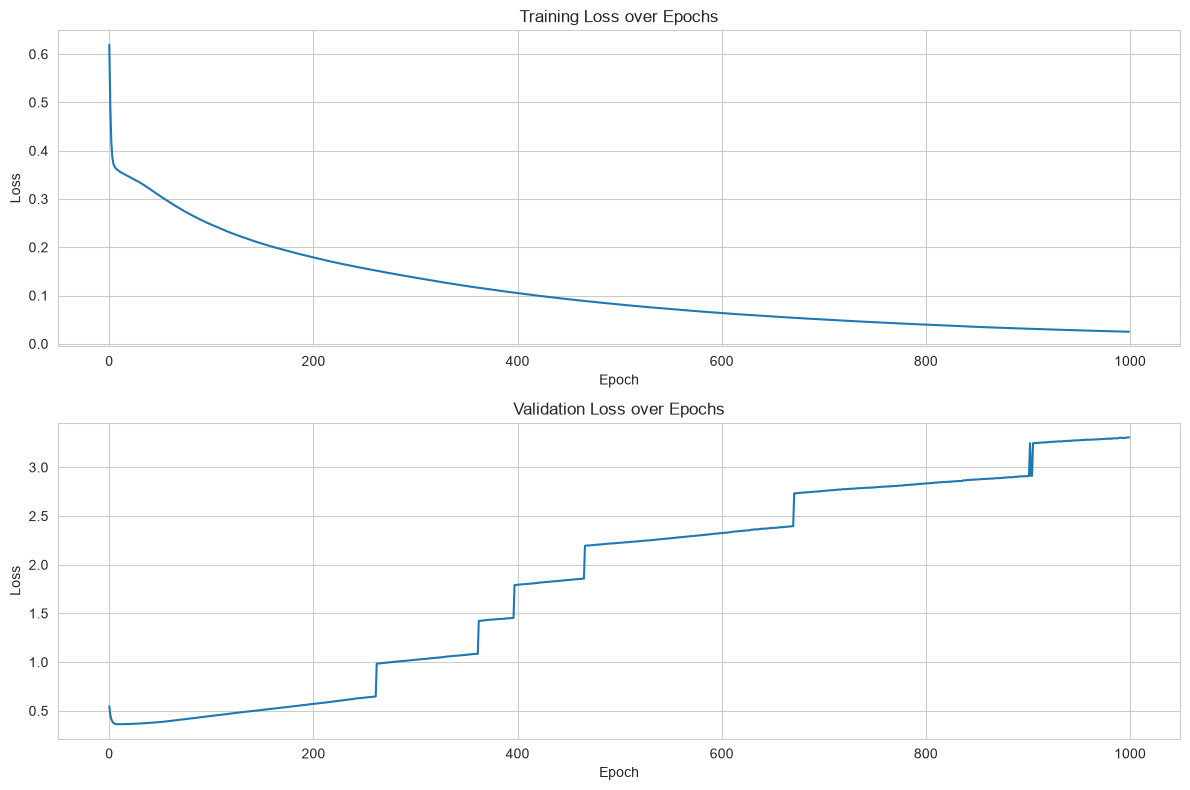

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(train_losses)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training Loss over Epochs")

ax[1].plot(val_losses)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_title("Validation Loss over Epochs")

plt.tight_layout()
plt.show()